# CustomerCluster
> Unsupervised customer segmentation · K-Means · Python

Grouping e-commerce customers by behaviour for smarter, targeted marketing.

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
df = pd.read_csv("smartcart_customers.csv")

In [150]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [151]:
df.shape

(2240, 22)

In [152]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### 1. Handling Missing Values 

In [153]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [154]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### 2. Feature Engineering

In [155]:
# Age is a more useful feature, than Year_Birth
df["Age"] = 2026 - df["Year_Birth"]

In [156]:
# Customer Tenure Days feature.

# Changing Dt_Customer values from objects to datetime.
#  Make sure to keep Day First for easier understanding.
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

#Reference Date is the date of the customer that is most recent, thus we dont need to do update this date.
reference_date = df["Dt_Customer"].max()


df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [157]:
# Total spending feature - added products in the shop.
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [158]:
# Total Children per customer - kid + teen.
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [159]:
# Education

df["Education"] = df["Education"].replace ({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})
# Instead of multiple class, we define all the classes in 3 basic academic level

In [160]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [161]:
# Marital Status - divide customer based on whether they have partners or not.

df["Living_With"] = df["Marital_Status"].replace ({
    "Married": "Partner", 
    "Together": "Partner",

    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### 3. Drop Unecessary Columns.

In [162]:
cols = ["ID", 
        "Year_Birth", 
        "Marital_Status",  
        "Kidhome", 
        "Teenhome", 
        "Dt_Customer"]

spending_cols = ['MntWines', 
                 'MntFruits',
                 'MntMeatProducts', 
                 'MntFishProducts', 
                 'MntSweetProducts',
                 'MntGoldProds']

df_cleaned = df.drop(columns=cols + spending_cols, axis=1)

In [163]:
df_cleaned.head(5)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers

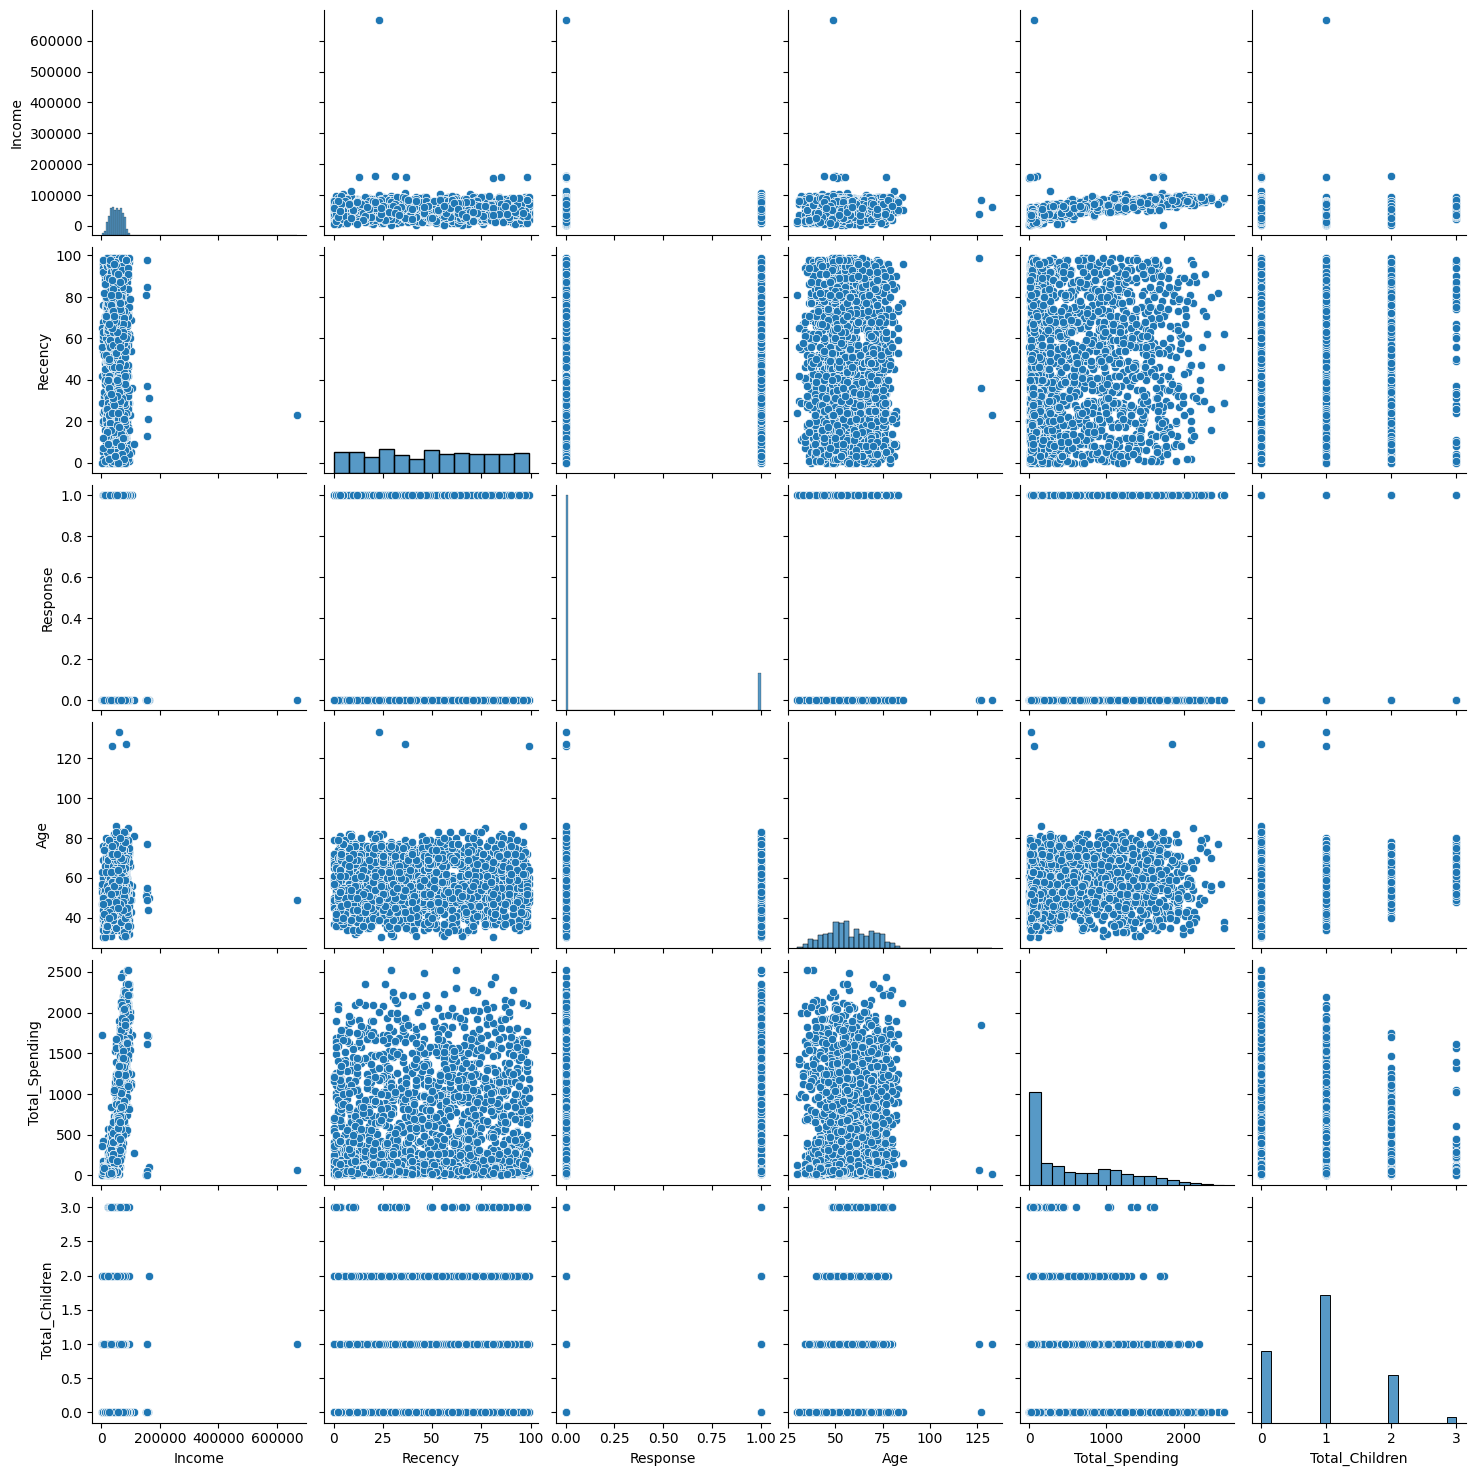

In [164]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Relative plots fo some features - Pair Plots.
sns.pairplot(df_cleaned[cols])

# As we can see age has outlier(age 120) and income of (600k+)

In [165]:
# Removing Outliers.
print("Data size with outliers: ", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000)]

print("Data size after removing outliers: ", len(df_cleaned))

Data size with outliers:  2240
Data size after removing outliers:  2236


## Heatmap

In [ ]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

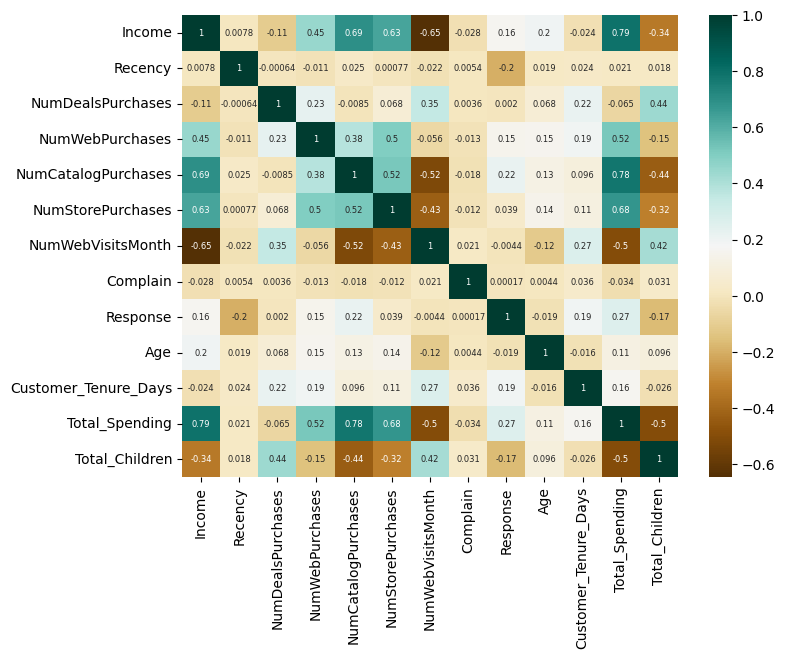

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="BrBG"
)

# Conclusive Data Points:
# 0.79 - Income - Total Spending
# 0.69 - Income - Catalog Product
# 0.63 - Income - Store Purchase
# -0.65 - Income - No of web visits
# 0.78 - Spending - Catalog Purchases
# 0.65 - Spending - Store Purchases

In [186]:
df_cleaned.head(5)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Feature Encoding

In [185]:
from sklearn.preprocessing import OneHotEncoder

In [188]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [ ]:
# Dont drop_first=True when u are clustering.
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [192]:
enc_df.head(5)

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [ ]:
# concatination of df_clean + enc_df, and dropping cat_cols.
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [194]:
df_encoded.head(5)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


## Scaling

In [195]:
from sklearn.preprocessing import StandardScaler

In [196]:
X = df_encoded

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# dataset is scaled and stored into X.

## Visualization

In [203]:
X_scaled.shape 

(2236, 18)

In [204]:
# 2D Visualization
from sklearn.decomposition import PCA

In [211]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca.explained_variance_ratio_
# ony (23 + 11+ 10)% of variance is being show, as we are compressing features from 18 to 3.

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

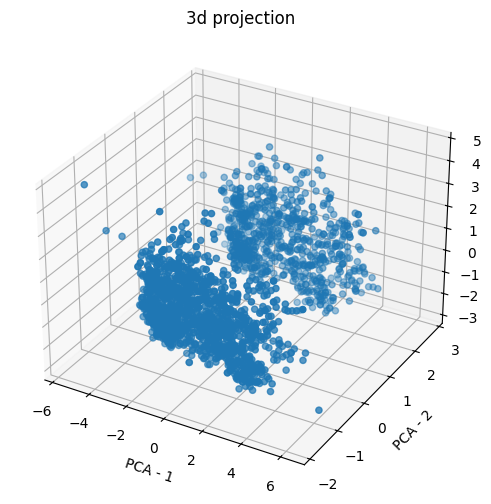

In [ ]:
# plotting
fig = plt.figure(figsize=(10, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
)

ax.set_xlabel("PCA - 1")
ax.set_ylabel("PCA - 2")
ax.set_zlabel("PCA - 3")
ax.set_title("3d projection")